# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import  f1_score, accuracy_score, recall_score, precision_score,confusion_matrix, roc_auc_score,classification_report, precision_recall_curve, roc_curve
from sklearn import tree

import warnings
warnings.filterwarnings("ignore")

#pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


In [ ]:
#import data
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ExtraaLearn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

- Observations
- Sanity checks

In [ ]:
df.head() #checking top entries in dataset

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [ ]:
df #view top and last entries in the dataset

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0


In [ ]:
#check shpae of data, data types, and if there are missing values
print(df.shape)
df.info()

(4612, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64 

In [ ]:
#checking counts of unique values for each variable
df.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


In [ ]:
#check if data contains duplicates
print(df.duplicated().sum())

0


###Data Overview Summary:


*   Data has 4,612 rows/observations and 15 variables/columns
*   Combination of continuous and categorical data
*   No duplicated data
*   Data contains no nulls
*   Variable of interest/target is the status of leads (did a lead convert to a paid customer)
*   ID column can be dropped for analysis



## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

In [ ]:
#ID of lead not needed for analysis
df = df.drop(columns=['ID'])

In [ ]:
#look at descriptive stats for continuous variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [ ]:
#view proportions of counts for each categorical column of interest. Not including ID since it will not be included in final analysis as column of interest

cat_columns = ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']

for column in cat_columns:
  print(df[column].value_counts(1))
  print('-'*25)

current_occupation
Professional    0.567216
Unemployed      0.312446
Student         0.120338
Name: proportion, dtype: float64
-------------------------
first_interaction
Website       0.551171
Mobile App    0.448829
Name: proportion, dtype: float64
-------------------------
profile_completed
High      0.490893
Medium    0.485906
Low       0.023200
Name: proportion, dtype: float64
-------------------------
last_activity
Email Activity      0.493929
Phone Activity      0.267563
Website Activity    0.238508
Name: proportion, dtype: float64
-------------------------
print_media_type1
No     0.892238
Yes    0.107762
Name: proportion, dtype: float64
-------------------------
print_media_type2
No     0.94948
Yes    0.05052
Name: proportion, dtype: float64
-------------------------
digital_media
No     0.885733
Yes    0.114267
Name: proportion, dtype: float64
-------------------------
educational_channels
No     0.847138
Yes    0.152862
Name: proportion, dtype: float64
-----------------------

Reviewing Distributions

In [ ]:
def histogram_boxplot(data, feature, figsize=(12,7), kde=True, bins=None):
  figure, (ax_box, ax_hist) = plt.subplots(2, sharex = True, figsize=figsize) #plotting boxplot and histogram, 2 rows, sharing x-axis, returns figure and tuple

  sns.boxplot(data=data, x = feature, ax = ax_box, showmeans= True, color = 'violet') #create boxplot

  if bins == None:
    sns.histplot(data = data, x = feature, kde = kde, ax = ax_hist) #create histogram
  else:
    sns.histplot(data = data, x = feature, kde = kde, ax = ax_hist, bins = bins)

  ax_hist.axvline(data[feature].mean(), color = 'green', linestyle = '--') #to view mean on plots
  ax_hist.axvline(data[feature].median(), color='black', linestyle = '-') #to view median on plots



Age

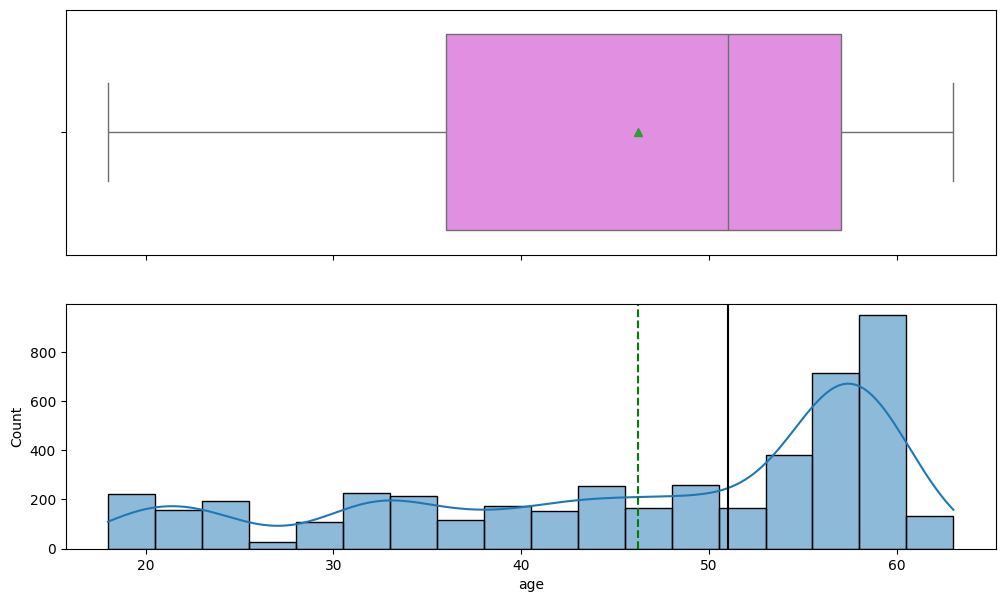

In [ ]:
histogram_boxplot(df, 'age')

Website Visits

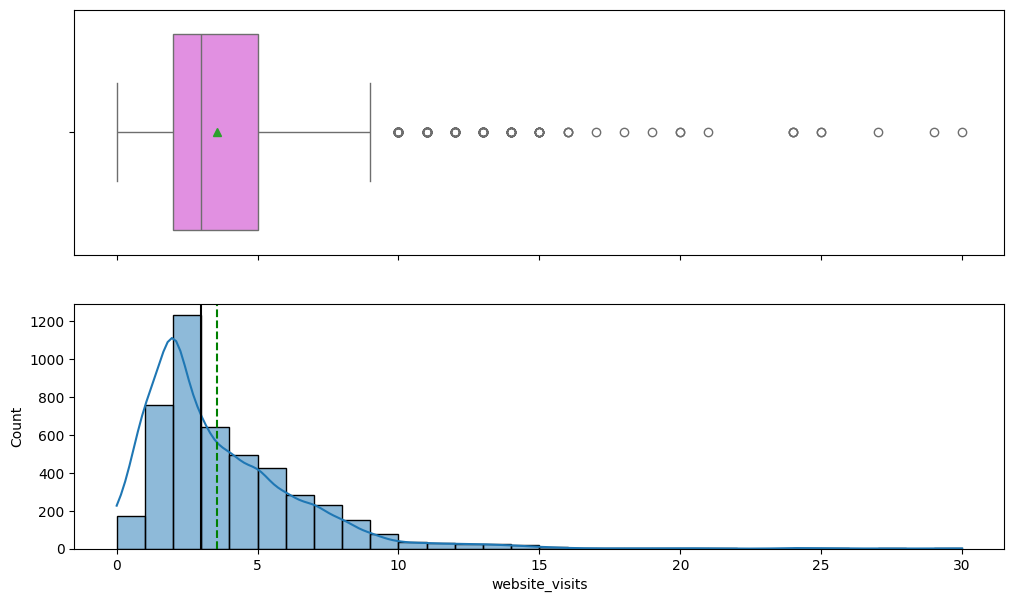

In [ ]:
histogram_boxplot(df, 'website_visits', bins = 30)

In [ ]:
#How many leads did not visit the site at all

print(f"Count not visited: {df[df["website_visits"] == 0].shape[0]}")
print(f"Count visited: {df[df["website_visits"] > 0].shape[0]}")

Count not visited: 174
Count visited: 4438


Time Spent on Site

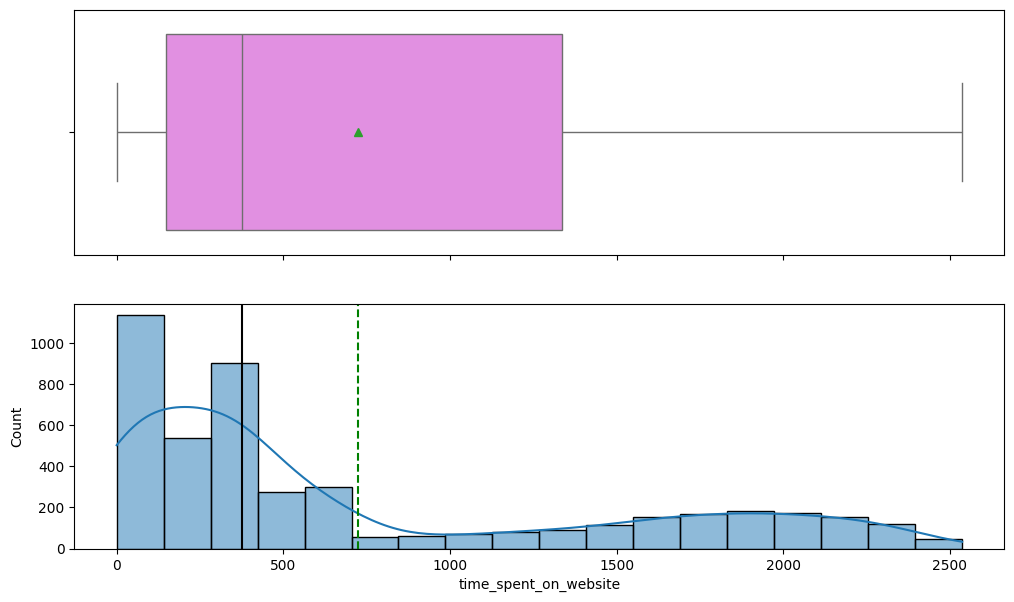

In [ ]:
histogram_boxplot(df, 'time_spent_on_website')

Page View Per Visit

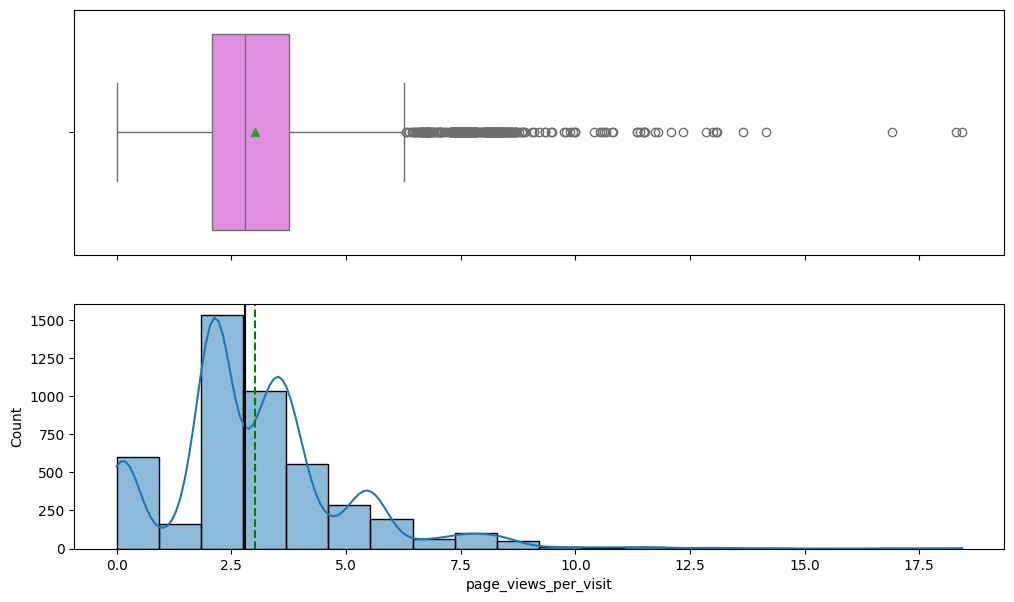

In [ ]:
histogram_boxplot(df, 'page_views_per_visit', bins = 20)

In [ ]:
#UDF for barplot for categorical variables

def plot_barplot(data, feature, hue =None, orient='v', figsize=(8,5), palette='viridis', decimal_places=1, title = None):
    fig, ax = plt.subplots(figsize=figsize)
    total = len(df)

    if orient == "v":
        sns.countplot(data=df, x=feature, hue=hue, palette=palette, ax=ax)
        for p in ax.patches:
            count = int(p.get_height())
            if count == 0:
                continue
            pct = f"{count / total * 100:.{decimal_places}f}%"
            ax.annotate(
                f"{count}\n({pct})",
                xy=(p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

        ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
        ax.set_xlabel(feature, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)

    elif orient == "h":
        sns.countplot(data=df, y=feature, hue=hue, palette=palette, ax=ax)
        for p in ax.patches:
            count = int(p.get_width())
            if count == 0:
                continue
            pct = f"{count / total * 100:.{decimal_places}f}%"
            ax.annotate(
                f"{count} ({pct})",
                xy=(p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

        ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel(feature, fontsize=11)

    ax.set_title(title if title else f"Distribution of {feature}", fontsize=13, fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    if hue:
        ax.legend(title=hue, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

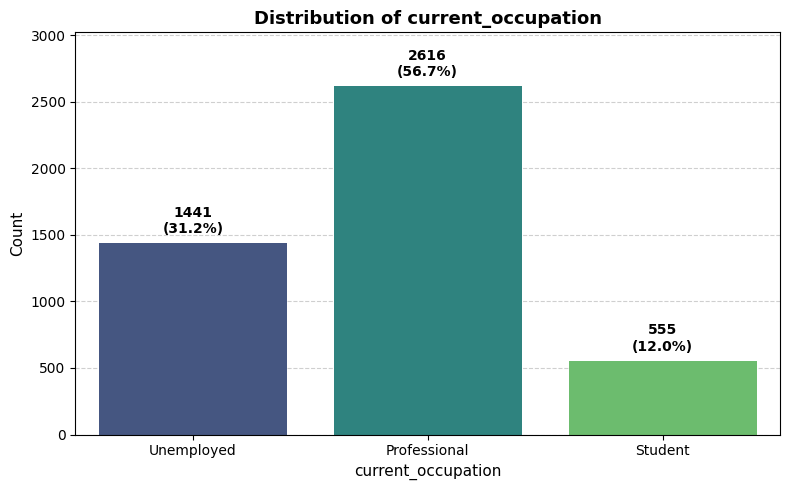

In [ ]:
plot_barplot(df, "current_occupation")

cat_columns = ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

First Interaction

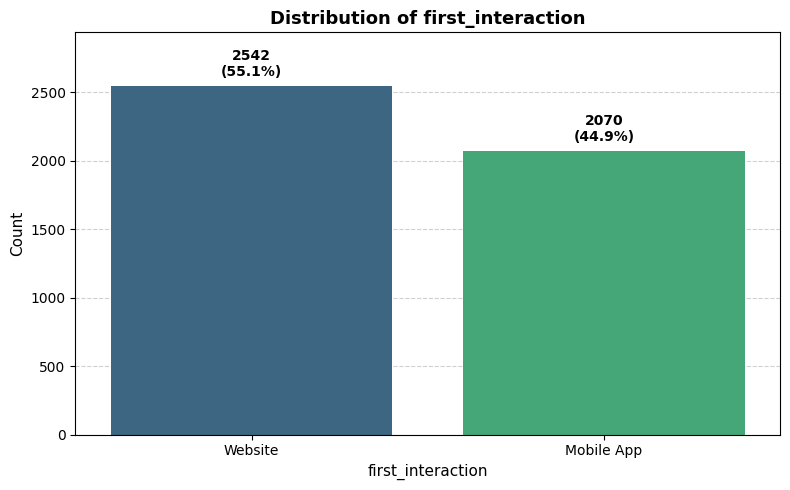

In [ ]:
plot_barplot(df, "first_interaction")

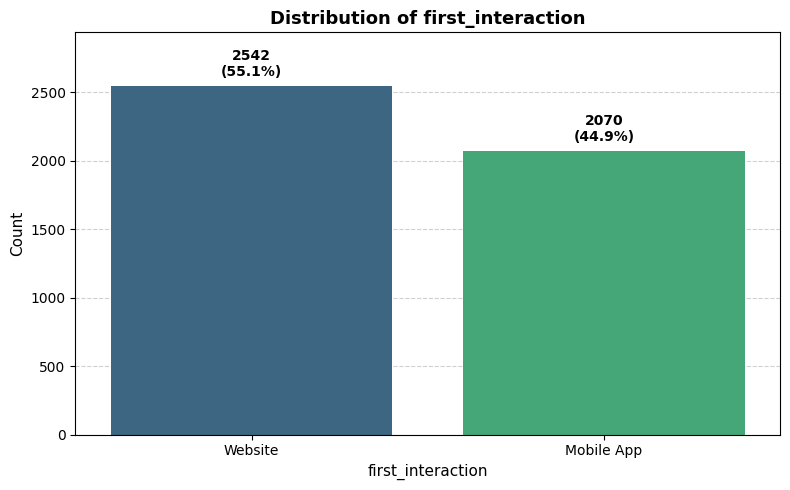

In [ ]:
plot_barplot(df, "first_interaction")

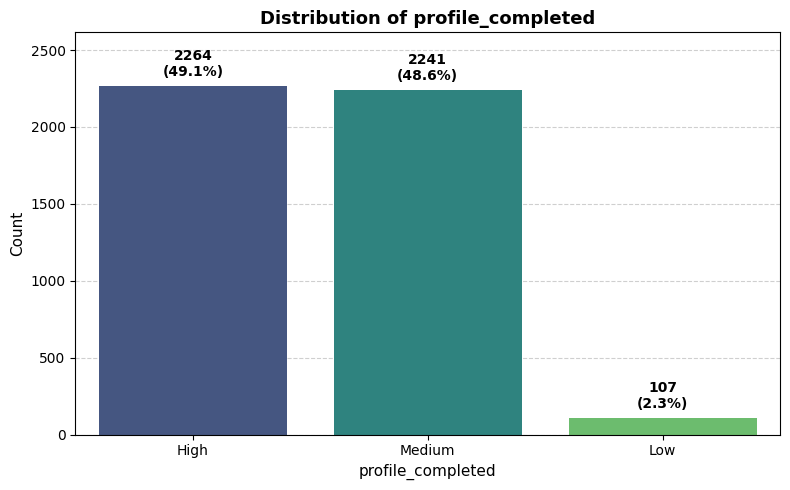

In [ ]:
plot_barplot(df, "profile_completed")

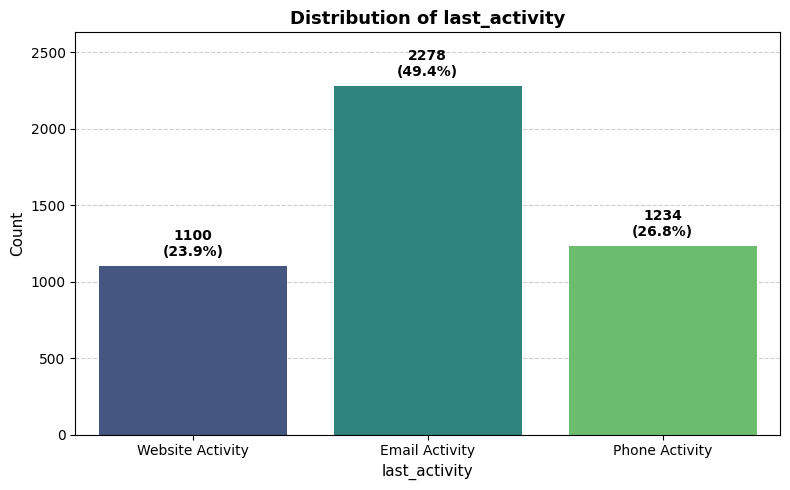

In [ ]:
plot_barplot(df, "last_activity")

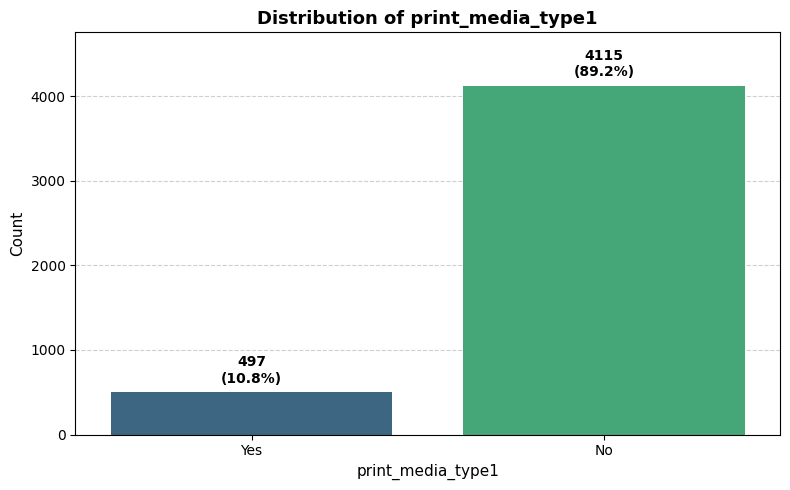

In [ ]:
plot_barplot(df, "print_media_type1")

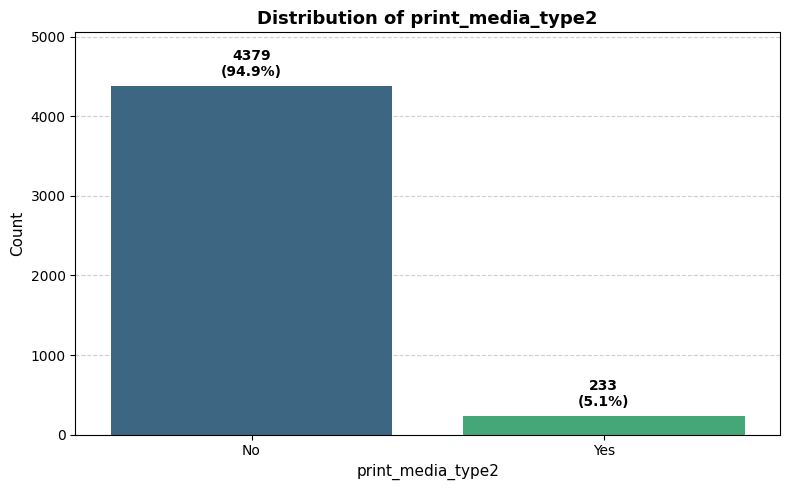

In [ ]:
plot_barplot(df, "print_media_type2")

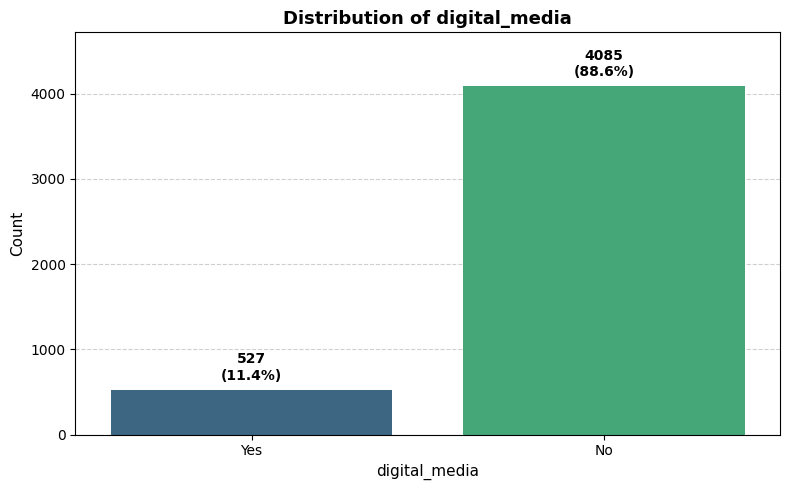

In [ ]:
plot_barplot(df, "digital_media")

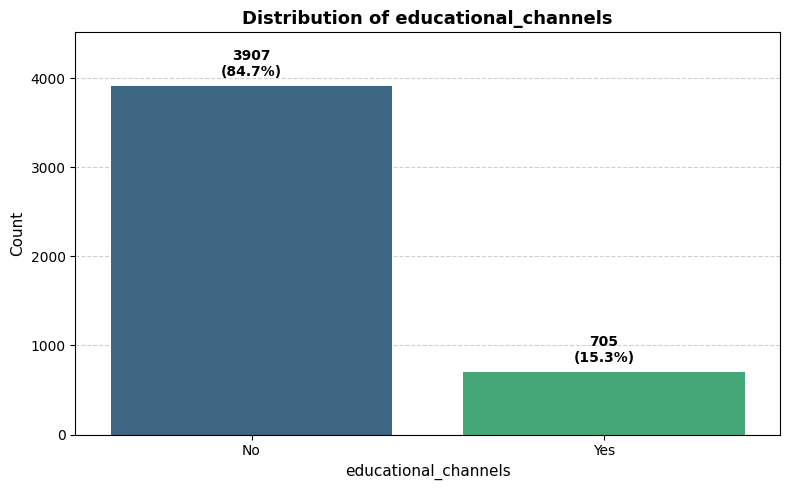

In [ ]:
plot_barplot(df, "educational_channels")

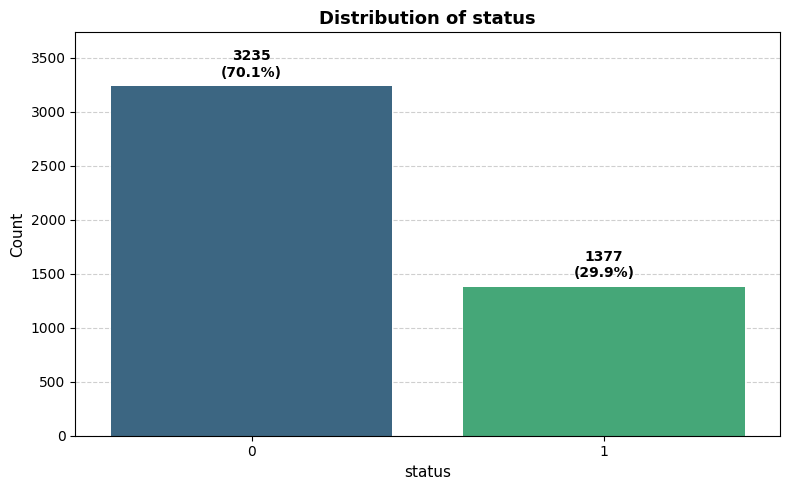

In [ ]:
plot_barplot(df, "status")

Bivariate Analysis

In [ ]:
data_numeric = df.select_dtypes(include='number')
data_numeric.corr()


,age,website_visits,time_spent_on_website,page_views_per_visit,status
age,1.000000,-0.011975,0.018885,-0.040675,0.122084
website_visits,-0.011975,1.000000,0.062300,0.074094,-0.006609
time_spent_on_website,0.018885,0.062300,1.000000,0.068130,0.302100
page_views_per_visit,-0.040675,0.074094,0.068130,1.000000,0.000307
status,0.122084,-0.006609,0.302100,0.000307,1.000000


<Axes: >

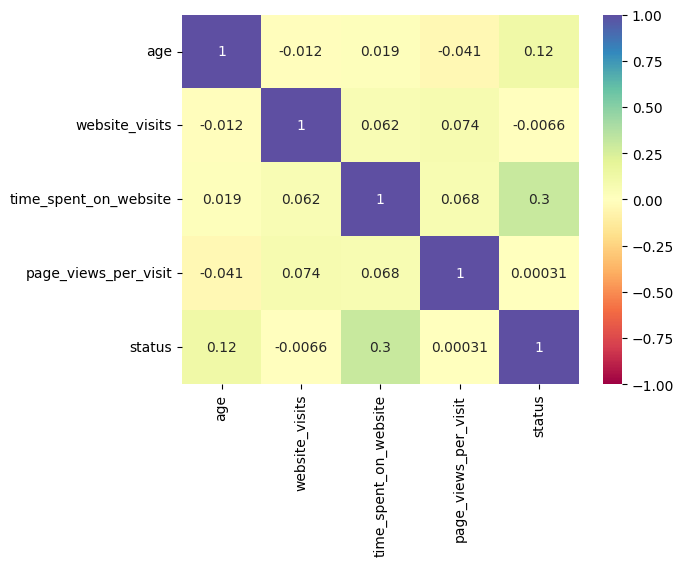

In [ ]:
sns.heatmap(data_numeric.corr(), annot = True, cmap = 'Spectral', vmin = -1, vmax = 1)

In [ ]:
def cramers_v(df, col, target):

    confusion_matrix = pd.crosstab(df[col], df[target])
    chi2 = stats.chi2_contingency(confusion_matrix, correction=False)[0]
    n = len(df)
    rows, cols = confusion_matrix.shape
    k = min(rows - 1, cols - 1)
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

    return {
        "cramers_v": v,
        "degrees_of_freedom": k,
        "n_categories": rows,       # number of categories in the predictor
        "table_shape": f"{rows}x{cols}",
    }


def get_strength(v: float, k: int) -> str:
    thresholds = {
        1: (0.10, 0.30),
        2: (0.07, 0.21),
        3: (0.06, 0.17),
        4: (0.05, 0.15),
    }
    weak_thresh, strong_thresh = thresholds.get(k, (0.05, 0.13))

    if v < weak_thresh:
        return "Weak"
    elif v < strong_thresh:
        return "Moderate"
    else:
        return "Strong"


def plot_cramers_v(
    df: pd.DataFrame,
    target: str,
    categorical_cols: list,
    figsize: tuple = (10, 6),
    palette: str = "PuBu",
    title: str = None,
):

    records = []
    for col in categorical_cols:
        result = cramers_v(df, col, target)
        result["feature"] = col
        result["strength"] = get_strength(result["cramers_v"], result["degrees_of_freedom"])
        records.append(result)

    results = (
        pd.DataFrame(records)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=results,
        x="cramers_v",
        y="feature",
        palette=palette,
        ax=ax,
    )

    for p in ax.patches:
        width = p.get_width()
        if width == 0:
            continue
        ax.annotate(
            f"{width:.3f}",
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
            clip_on=False,
        )

    ax.set_title(
        title if title else f"Cramér's V Association with '{target}'",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Cramér's V", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)
    ax.xaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # Print interpretation table
    print("\nInterpretation Summary:")
    print(
        results[["feature", "cramers_v", "n_categories", "degrees_of_freedom", "table_shape", "strength"]]
        .to_string(index=False)
    )

    return results

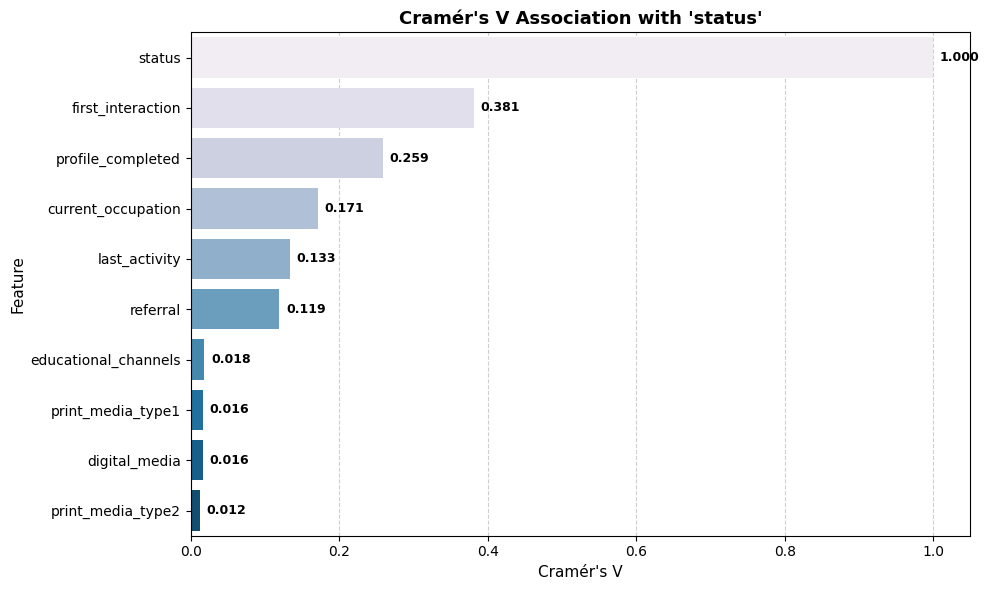


Interpretation Summary:
             feature  cramers_v  n_categories  degrees_of_freedom table_shape strength
              status   1.000000             2                   1         2x2   Strong
   first_interaction   0.381077             2                   1         2x2   Strong
   profile_completed   0.258603             3                   1         3x2 Moderate
  current_occupation   0.170835             3                   1         3x2 Moderate
       last_activity   0.133412             3                   1         3x2 Moderate
            referral   0.118761             2                   1         2x2 Moderate
educational_channels   0.017763             2                   1         2x2     Weak
   print_media_type1   0.016214             2                   1         2x2     Weak
       digital_media   0.015867             2                   1         2x2     Weak
   print_media_type2   0.011754             2                   1         2x2     Weak
   cramers_v  degr

In [ ]:
results = plot_cramers_v(df, target='status', categorical_cols=cat_columns)

print(results)

In [ ]:
def stacked_barplot(data, predictor, target):
  count = data[predictor].nunique()
  sorter = data[target].value_counts().index[-1]
  tab1 = pd.crosstab(data[predictor], data[target]).sort_values(by = sorter, ascending = False)
  print(tab1)
  tab = pd.crosstab(data[predictor], data[target], normalize= 'index').sort_values(by=sorter, ascending=False)

  tab.plot(kind = 'bar', stacked = True, figsize= (count +1, 5))
  plt.legend(loc='upper left', bbox_to_anchor = (1,1), frameon= True)

status                 0    1
current_occupation           
Professional        1687  929
Unemployed          1058  383
Student              490   65


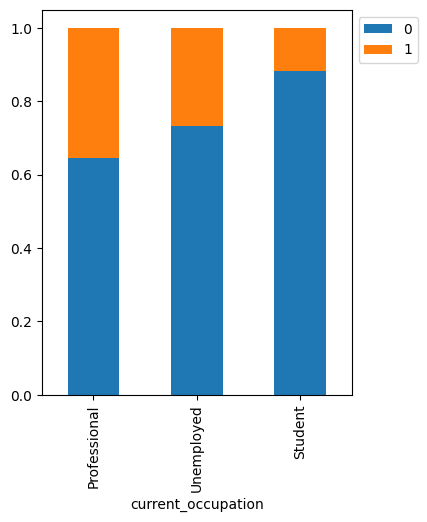

In [ ]:
stacked_barplot(df, 'current_occupation', 'status')

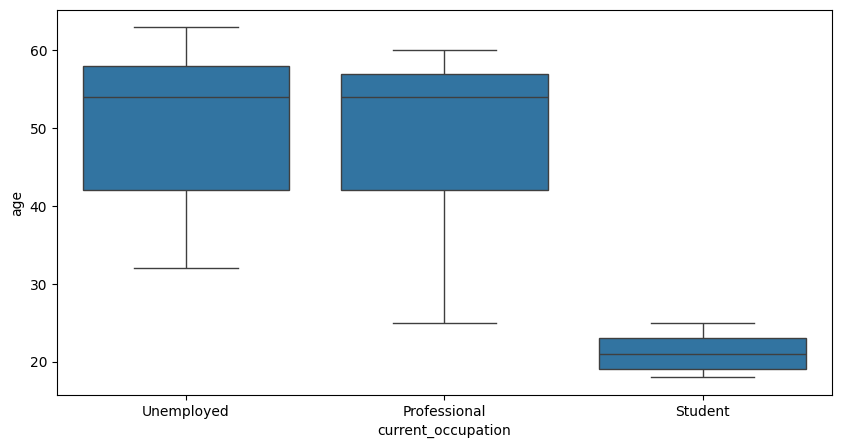

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="current_occupation", y="age", data=df)
plt.show()

In [ ]:
df.groupby(["current_occupation"])["age"].describe()

,count,mean,std,min,25%,50%,75%,max
current_occupation,,,,,,,,
Professional,2616.0,49.347477,9.890744,25.0,42.0,54.0,57.0,60.0
Student,555.0,21.144144,2.001114,18.0,19.0,21.0,23.0,25.0
Unemployed,1441.0,50.140180,9.999503,32.0,42.0,54.0,58.0,63.0


status                0    1
profile_completed           
High               1318  946
Medium             1818  423
Low                  99    8


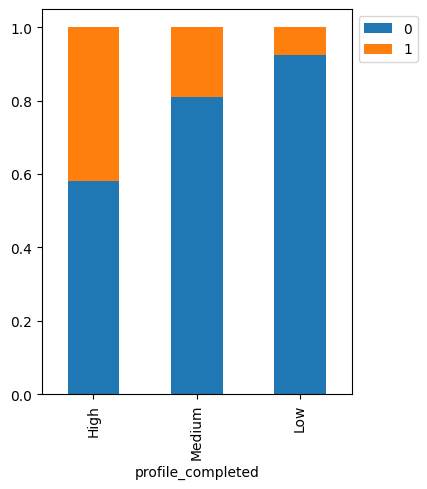

In [ ]:
stacked_barplot(df, 'profile_completed', 'status')

status                0     1
first_interaction            
Website            1383  1159
Mobile App         1852   218


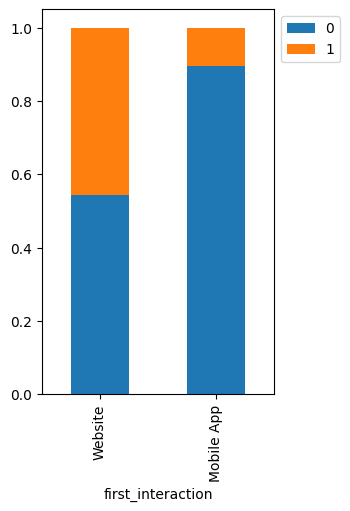

In [ ]:
stacked_barplot(df, 'first_interaction', 'status')

status               0    1
last_activity              
Email Activity    1587  691
Website Activity   677  423
Phone Activity     971  263


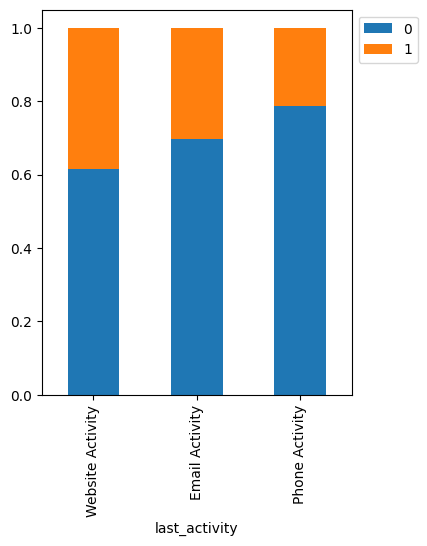

In [ ]:
stacked_barplot(df, 'last_activity', 'status')

status       0     1
referral            
No        3205  1314
Yes         30    63


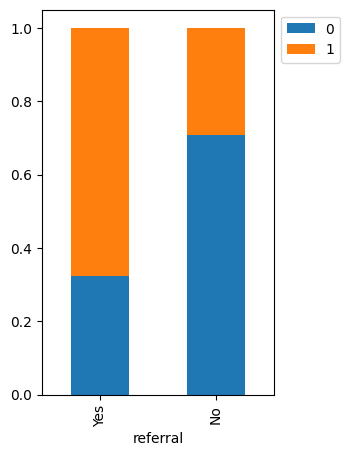

In [ ]:
stacked_barplot(df, 'referral', 'status')

status                0     1
print_media_type1            
No                 2897  1218
Yes                 338   159


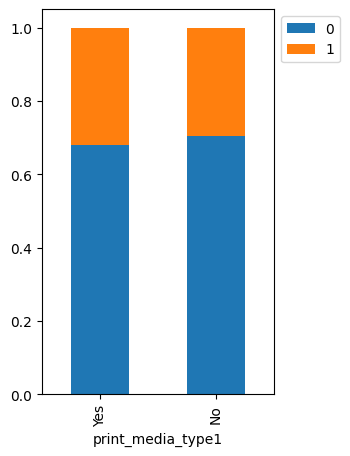

In [ ]:
stacked_barplot(df, 'print_media_type1', 'status')

status                0     1
print_media_type2            
No                 3077  1302
Yes                 158    75


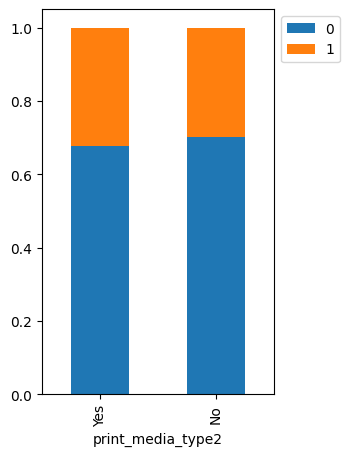

In [ ]:
stacked_barplot(df, 'print_media_type2', 'status')

status            0     1
digital_media            
No             2876  1209
Yes             359   168


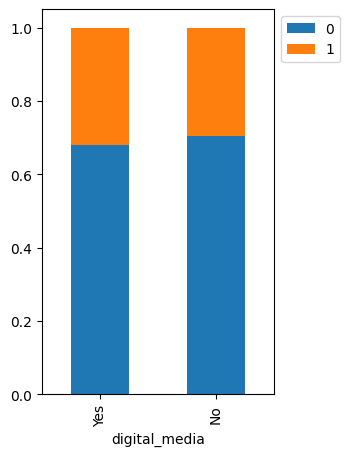

In [ ]:
stacked_barplot(df, 'digital_media', 'status')

###EDA Summary and Question Answers
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
    - Current occupation does affect lead status. The data shows professionals are more likely to convert to customers, followed by unemployed and finally students making up the least likely group. Professionals converted about 35% of the time, whereas students were around 11-12% of the time. Additionally, this means age plays a key role in conversion. Students average age is around 21, and both professionals and unemployed leads are around 50  
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
    - The first channels of interaction does have an impact. Approximatley 45% of leads of whose first interaction was the website resulted in converting to a sale about 45% of the time versus only about 10% converting when their first interaction was through the mobile site
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
    - Email activity had the most interactions of leads making up about 50% of interactions, with phone and website interactions making up the other 50% at an almost even split. Phone activity was about 3% higher than website.While website activity had the least interactions, it is the interaction most likley to lead to a paying customer with almost 39% converting, followed by email at 30% converting and lastly phone around 21% converting.
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
    - Referrals have the highest conversion rate at around 2/3 converting. However, they also have one of the lowest raw numbers of leads exposed.
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?
    - Yes. Leads who have filled out 75-100% of profile (high completion) resulted in a conversion over 40% of the time. While those with 50-75% (medium completion) only converted about 18-19% and those with 0-50% completed (low completion) only converted around 7%.

Additional Observations:
 * When looking at continuous variables, there is evidence to suggest time spent on the website may impact if a lead converts more than other continous variables
 * Using Cramers V measure for categorical variables, it appears variables such as first interaction, profile completion, and current occupation have a greater impact on status of leads than other variables.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

###Preprocessing Observations:
 * There are outliers within website visits and page views per visit. Given a decision tree is robust enough to handle outliers and can sometimes be important to the splits, noting they exist but leaving them in the data as they are
 * There is no missing data
 * Encoded categorical variables
 * Split the data into training and testing with 70/30 split

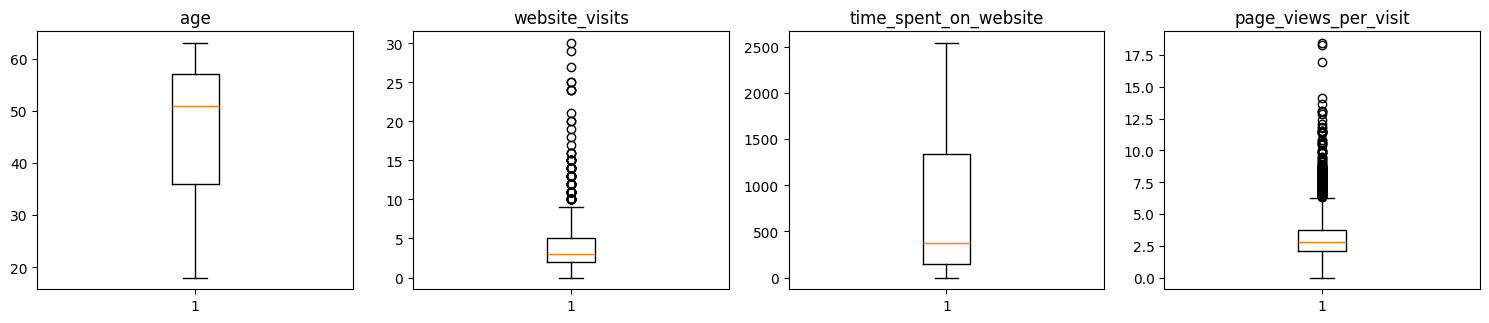

In [ ]:
#outlier detection
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
df.select_dtypes(include = ['object', 'category']).columns.tolist()

['current_occupation',
 'first_interaction',
 'profile_completed',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral']

In [ ]:
#Encode categorical variables
df_prep = pd.get_dummies(
    df,
    columns = df.select_dtypes(include = ['object', 'category']).columns.tolist(),
    #drop_first = True
)


In [ ]:
df_prep

,age,website_visits,time_spent_on_website,page_views_per_visit,status,current_occupation_Professional,current_occupation_Student,current_occupation_Unemployed,first_interaction_Mobile App,first_interaction_Website,profile_completed_High,profile_completed_Low,profile_completed_Medium,last_activity_Email Activity,last_activity_Phone Activity,last_activity_Website Activity,print_media_type1_No,print_media_type1_Yes,print_media_type2_No,print_media_type2_Yes,digital_media_No,digital_media_Yes,educational_channels_No,educational_channels_Yes,referral_No,referral_Yes
0,57,7,1639,1.861,1,False,False,True,False,True,True,False,False,False,False,True,False,True,True,False,False,True,True,False,True,False
1,56,2,83,0.320,0,True,False,False,True,False,False,False,True,False,False,True,True,False,True,False,True,False,False,True,True,False
2,52,3,330,0.074,0,True,False,False,False,True,False,False,True,False,False,True,True,False,True,False,False,True,True,False,True,False
3,53,4,464,2.057,1,False,False,True,False,True,True,False,False,False,False,True,True,False,True,False,True,False,True,False,True,False
4,23,4,600,16.914,0,False,True,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,35,15,360,2.170,0,False,False,True,True,False,False,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False
4608,55,8,2327,5.393,0,True,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False
4609,58,2,212,2.692,1,True,False,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,False,True,False
4610,57,1,154,3.879,0,True,False,False,True,False,False,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False


In [ ]:
#split into x and y variables

x = df_prep.drop('status', axis = 1) #target variable
y = df_prep['status']


In [ ]:
y.shape

(4612,)

In [ ]:
#split training and testing data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, shuffle = True, random_state=1)

In [ ]:
x_train.shape, x_test.shape

((3228, 25), (1384, 25))

## Building a Decision Tree model

In [ ]:
#building decision tree model
#Since frequency of converted is about 30% vs 70% leads not converted, adding class weight hyperparameter for the decision tree to help prevent the model from being biased towards class 0
dt = DecisionTreeClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)

In [ ]:
#fitting decision tree model
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, random_state=1)

In [ ]:
dt.get_params()

{'ccp_alpha': 0.0,
 'class_weight': {0: 0.3, 1: 0.7},
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

## Model Performance evaluation and improvement

###Model Evaluation Criterion
The model can make two types of wrong predictions:
  1. Predicting a lead will convert to a payig customer when they won't convert
  2. Predicting a lead will not convert to a paying customer when they will

Emphasis for modeling:
 * While mis identifying leads as ones who will convert may waste resources, identifyig leads as ones who will not convert when they would results in more revenue loss. Due to this, recall will want to be maximized or minimizing false negatives. This will lead to the organization being able to receive maximum revenue.

Model Evaluation:
 * To evaluate the model we'll use the confusion matrix, recall, precision, and accuracy though recall will be the metric of most interest

In [ ]:
def metrics_score(actual, predicted):

  print(classification_report(actual, predicted))
  cm = confusion_matrix(actual, predicted)
  plt.figure(figsize=(8,5))

  sns.heatmap(cm, annot = True, fmt='.2f', xticklabels= ['Not Converted', 'Converted'], yticklabels = ['Not Converted', 'Converted'])
  plt.ylabel('Actual')
  plt.xlabel('Predicted')

  plt.show()

In [ ]:
def model_performance_classification(model, predictors, target):
  pred = model.predict(predictors)
  recall = recall_score(target, pred,average = 'macro')
  precision = precision_score(target, pred, average = 'macro')
  acc = accuracy_score(target, pred)

  # Creating a dataframe of metrics
  df_perf = pd.DataFrame(
      {
          "Precision":  precision,
          "Recall":  recall,
          "Accuracy": acc,
      },
      index = [0],
    )
  return df_perf

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



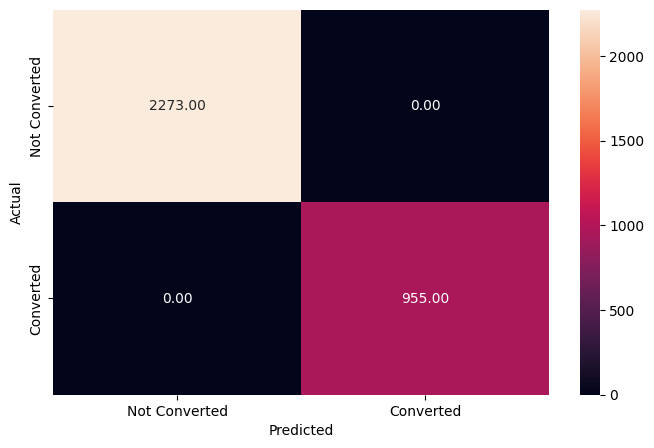

In [ ]:
#checking performance on the training dataset
y_train_pred_dt = dt.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

###Performance on training data
 * The model on the training data accuratley classified every instance, likely overfitting the model. This is not unexpected when working with decision trees.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       962
           1       0.68      0.68      0.68       422

    accuracy                           0.81      1384
   macro avg       0.77      0.77      0.77      1384
weighted avg       0.81      0.81      0.81      1384



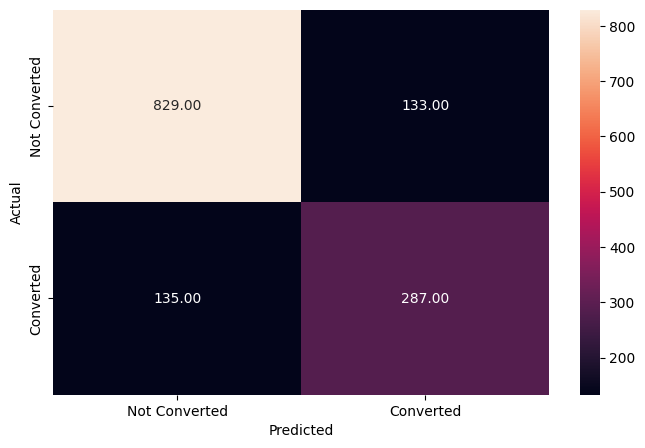

In [ ]:
#checking performance on test dataset
y_test_pred_dt = dt.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

In [ ]:
dtree_test = model_performance_classification(dt, x_test, y_test)
dtree_test

,Precision,Recall,Accuracy
0,0.771646,0.770921,0.806358


In [ ]:
features = list(x.columns)
features

['age',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'current_occupation_Professional',
 'current_occupation_Student',
 'current_occupation_Unemployed',
 'first_interaction_Mobile App',
 'first_interaction_Website',
 'profile_completed_High',
 'profile_completed_Low',
 'profile_completed_Medium',
 'last_activity_Email Activity',
 'last_activity_Phone Activity',
 'last_activity_Website Activity',
 'print_media_type1_No',
 'print_media_type1_Yes',
 'print_media_type2_No',
 'print_media_type2_Yes',
 'digital_media_No',
 'digital_media_Yes',
 'educational_channels_No',
 'educational_channels_Yes',
 'referral_No',
 'referral_Yes']

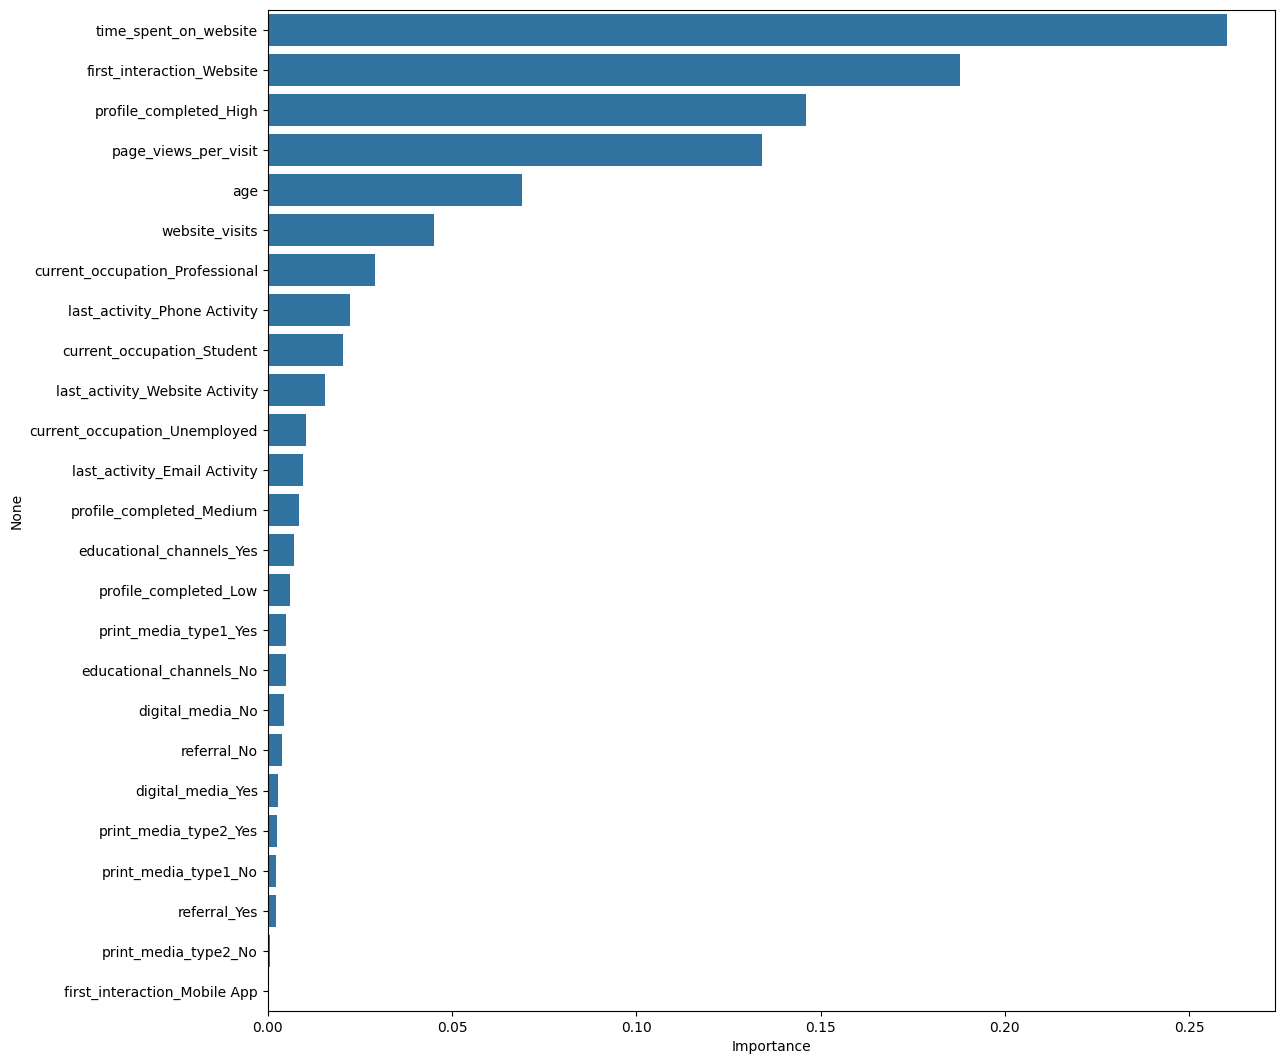

In [ ]:
#plotting feature importance
#importance can be biased toward variables with high cardinality i.e. biased towards continous variables, then categorical with higher number of categories, then categorical with lower number of categories

importances = dt.feature_importances_
columns= x.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by='Importance', ascending = False)

plt.figure(figsize=(13,13))
sns.barplot(x=importance_df.Importance, y=importance_df.index);


###Test Data Performance
 * The model is overfitting as expected. Overall recall is sitting around 0.77, but the recall for class 1 (converting to paying customer) is sitting even lower at 0.68. To help correct this, hyperparameter tuning can be done using GridSearch
 * According to the decision tree, the most important features are time spent on website, the first interaction being the website, and high completion of profile.

In [ ]:
# #visualize the tree
# features = list(x.columns)

# plt.figure(figsize=(30, 20))
# tree.plot_tree(dt, max_depth = 3,feature_names=features, filled = True, fontsize = 12, node_ids = True, class_names = None)

# plt.show()

###Hyperparameter Tuning

In [ ]:
#trying to improve model with hyperparamter tuning using gridsearch

dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)

#grid of paremeters to choose from
parameters = {'max_depth': np.arange(2,15),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5,10,20,25]
              }

scorer = metrics.make_scorer(recall_score, pos_label = 1)

#run grid search
gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 10)

#fitting the grid search on train data
gridCV = gridCV.fit(x_train, y_train)

#set the classifier to the best combination of parameters
dtree_estimator = gridCV.best_estimator_

#Fit best estimator to the data
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(3), min_samples_leaf=5,
                       random_state=1)

In [ ]:
dtree_estimator.get_params()


{'ccp_alpha': 0.0,
 'class_weight': {0: 0.3, 1: 0.7},
 'criterion': 'entropy',
 'max_depth': np.int64(3),
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [ ]:
print("Total tree depth:", dtree_estimator.get_params()["max_depth"])

Total tree depth: 3


              precision    recall  f1-score   support

           0       0.94      0.77      0.85      2273
           1       0.62      0.88      0.73       955

    accuracy                           0.80      3228
   macro avg       0.78      0.83      0.79      3228
weighted avg       0.84      0.80      0.81      3228



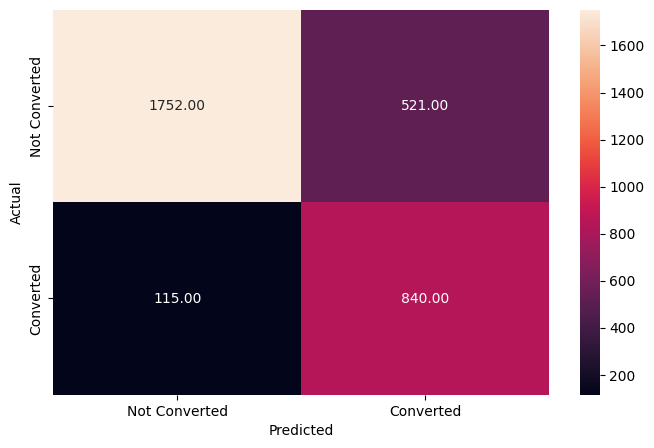

In [ ]:
#checking performance on the training dataset
y_train_pred_dt = dtree_estimator.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

Model performance on training dataset after hyperparameter tuning has decreased which is expected as we are tryig to reduce overfitting

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       962
           1       0.62      0.86      0.72       422

    accuracy                           0.80      1384
   macro avg       0.77      0.82      0.78      1384
weighted avg       0.83      0.80      0.80      1384



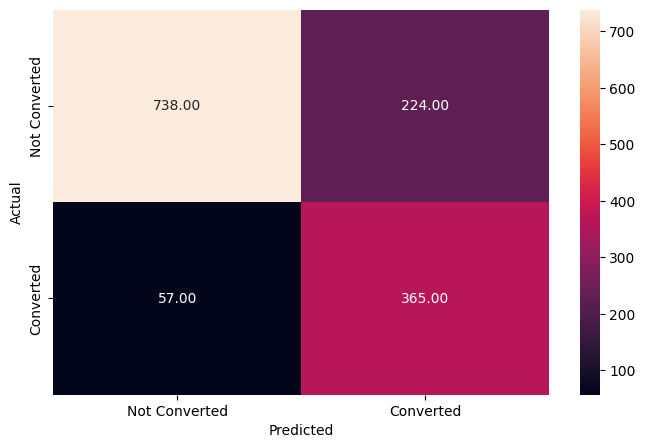

In [ ]:
# Checking performance on the test dataset
y_test_pred_dt = dtree_estimator.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

In [ ]:
dtree_tuned_test = model_performance_classification(dtree_estimator,x_test,y_test)
dtree_tuned_test

,Precision,Recall,Accuracy
0,0.773998,0.81604,0.796965


The overall recall has improved from the model with default hypermeters.

###Perfmance of Tuned Decision Tree Model
 * Overfitting appears to be less of an issue here. While overall recall is only at 0.81, the recall for the target of interest is at 0.86.


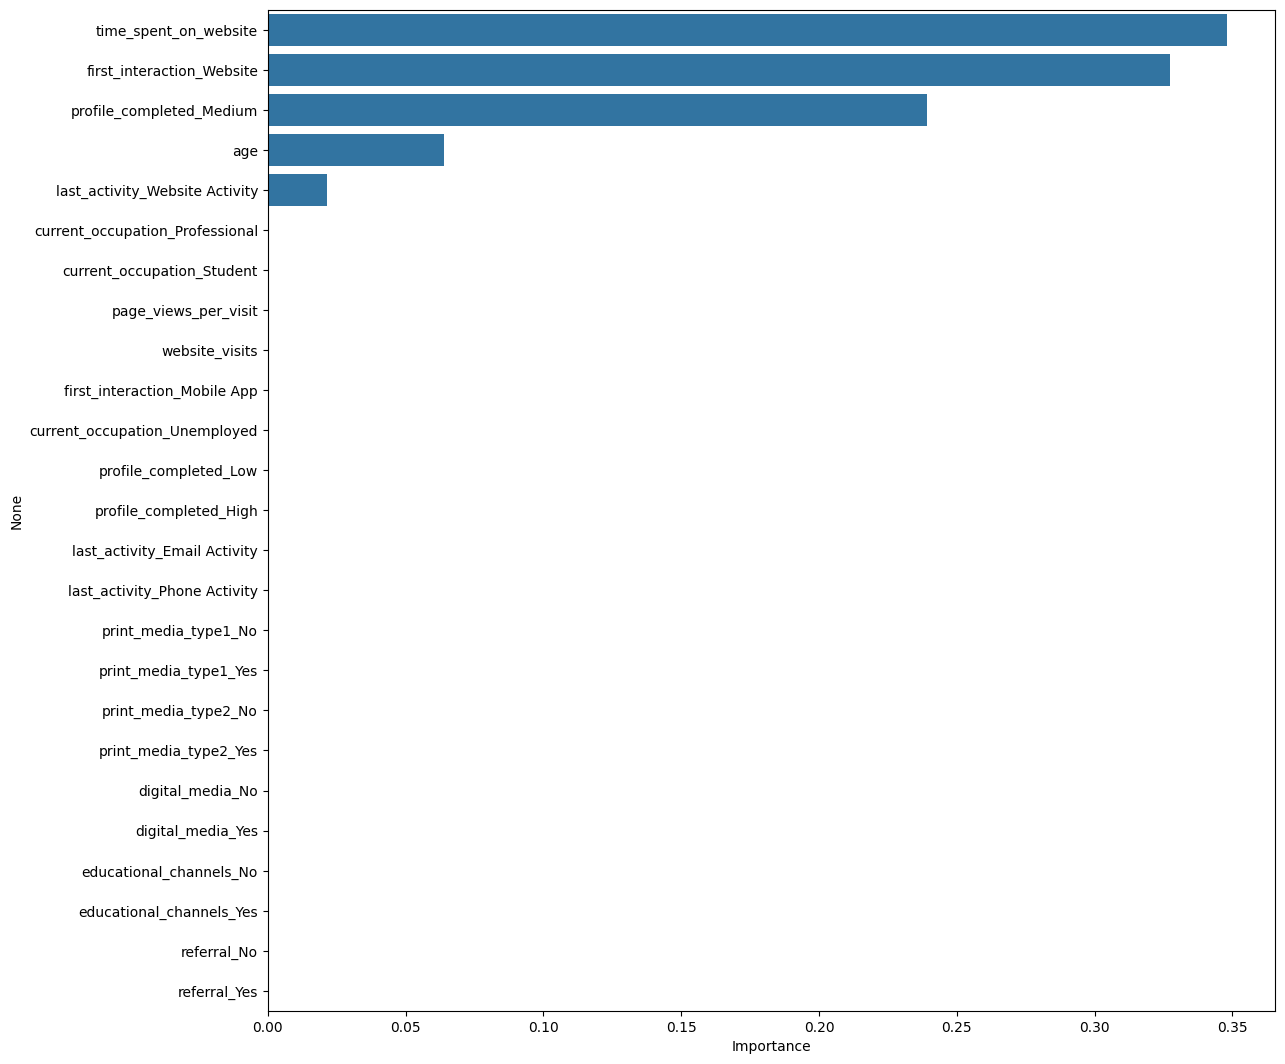

In [ ]:
#feature importance of tuned model using grid search

importances = dtree_estimator.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y= importance_df.index);

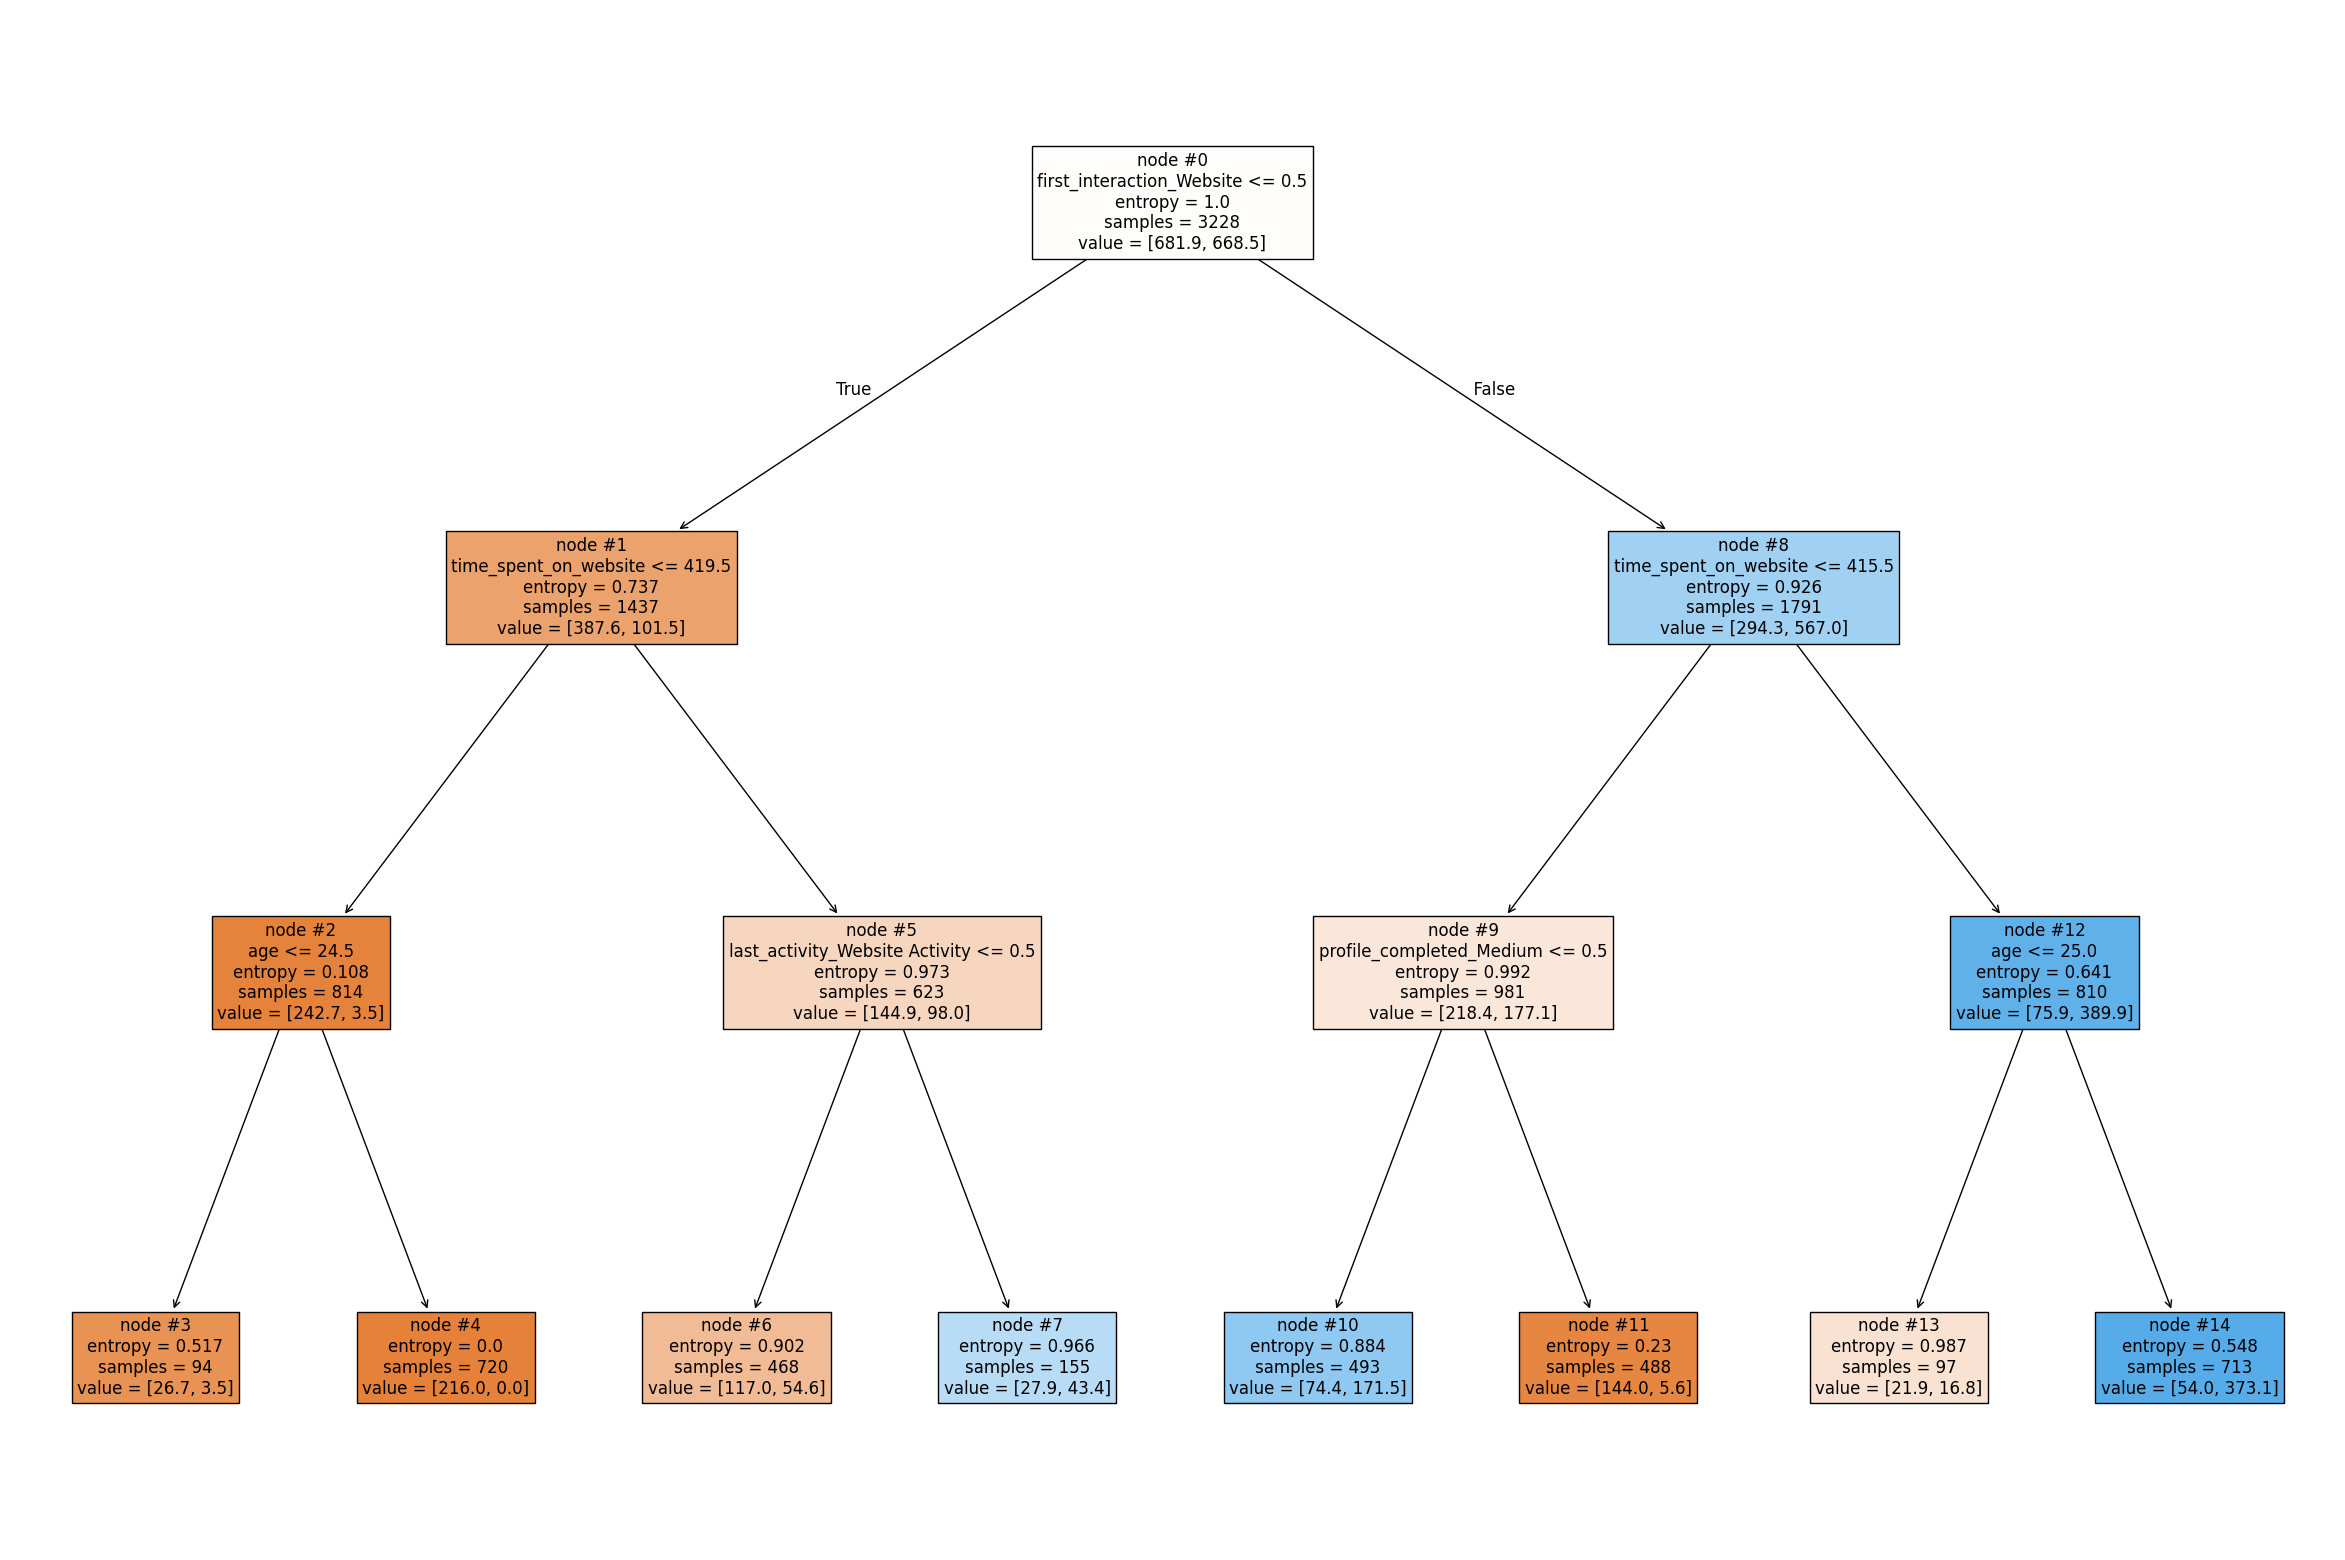

In [ ]:
#visualize the tuned tree
features = list(x.columns)

plt.figure(figsize=(30, 20))
tree.plot_tree(dtree_estimator, max_depth = 3,feature_names=features, filled = True, fontsize = 12, node_ids = True, class_names = None)

plt.show()


Individuals whose first interactions were with the website, spent longer than 415.5 on the website, and are over the age 25 are more likely to convert.

## Building a Random Forest model

In [ ]:
#Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)
rf_estimator.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, random_state=1)

## Model Performance evaluation and improvement

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



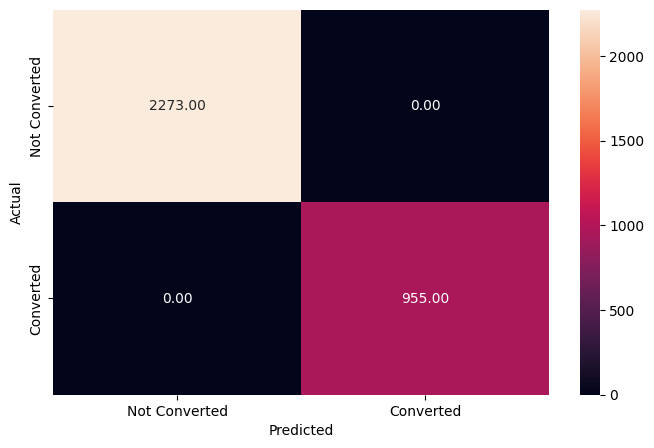

In [ ]:
#checking performance on the training data
y_pred_train_rf = rf_estimator.predict(x_train)
metrics_score(y_train, y_pred_train_rf)

              precision    recall  f1-score   support

           0       0.87      0.92      0.90       962
           1       0.80      0.69      0.74       422

    accuracy                           0.85      1384
   macro avg       0.84      0.81      0.82      1384
weighted avg       0.85      0.85      0.85      1384



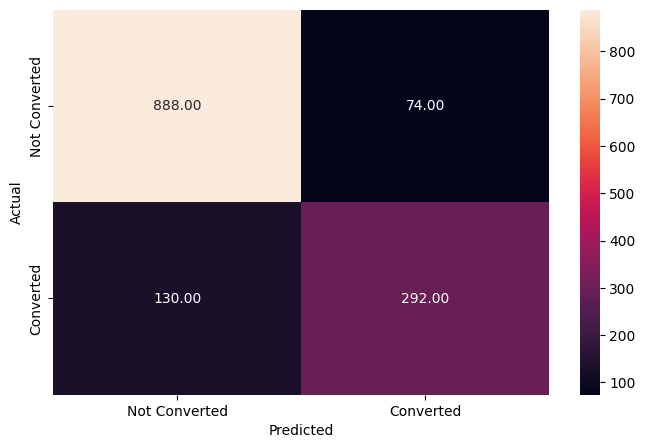

In [ ]:
#checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(x_test)
metrics_score(y_test, y_pred_test_rf)

In [ ]:
rf_estimator_test = model_performance_classification(rf_estimator,x_test,y_test)
rf_estimator_test

,Precision,Recall,Accuracy
0,0.835056,0.80751,0.852601


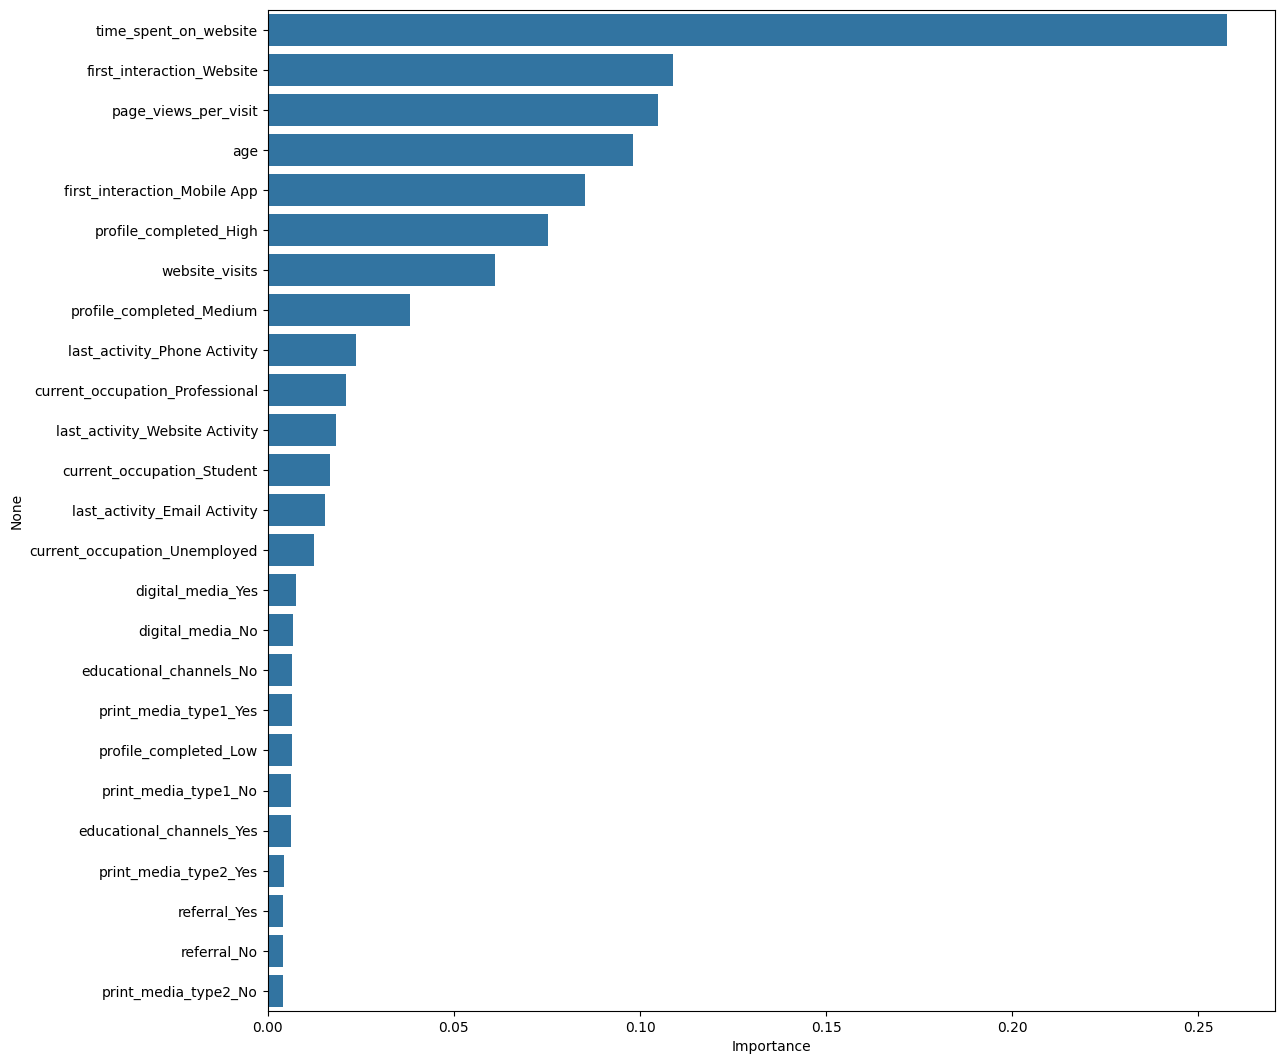

In [ ]:
#checking importance of random forest
importances = rf_estimator.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y=importance_df.index);

###Hyperparameter Tuning

In [ ]:
#Tuning the Random Forest Classifier
rf_estimator_tuned = RandomForestClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)

#Grid of parameters to choose from
parameters_rf = {
    'n_estimators': [100, 250, 500],
    'min_samples_leaf': np.arange(1, 4, 1),
    'max_features': [0.7, 0.9, 'sqrt'],
    'min_samples_split': [2,5,10],
}

#type of scoring used to compare parameter combinations - recall score for target class 1
scorer = metrics.make_scorer(recall_score, pos_label=1)

#run grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters_rf, scoring = scorer, cv = 5)
grid_obj = grid_obj.fit(x_train, y_train)

#set the classifier to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

In [ ]:
rf_estimator_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7},
                       min_samples_leaf=np.int64(3), min_samples_split=10,
                       n_estimators=500, random_state=1)

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2273
           1       0.83      0.90      0.86       955

    accuracy                           0.91      3228
   macro avg       0.89      0.91      0.90      3228
weighted avg       0.92      0.91      0.91      3228



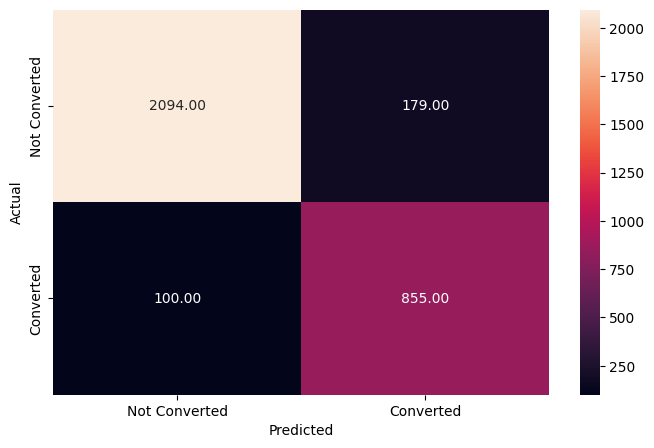

In [ ]:
#checking performance on the training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(x_train)
metrics_score(y_train, y_pred_train_rf_tuned)

In [ ]:
rf_estimator_tuned_train = model_performance_classification(rf_estimator_tuned, x_train, y_train)
rf_estimator_tuned_train

,Precision,Recall,Accuracy
0,0.890654,0.908269,0.913569


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       962
           1       0.77      0.78      0.77       422

    accuracy                           0.86      1384
   macro avg       0.84      0.84      0.84      1384
weighted avg       0.86      0.86      0.86      1384



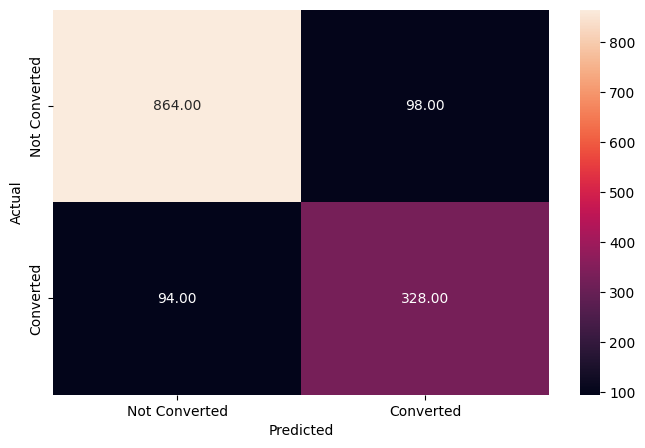

In [ ]:
#checking performance on the test data
y_pred_test_rf_tuned = rf_estimator_tuned.predict(x_test)
metrics_score(y_test, y_pred_test_rf_tuned)

In [ ]:
rf_estimator_tuned_test = model_performance_classification(rf_estimator_tuned, x_test, y_test)
rf_estimator_tuned_test

,Precision,Recall,Accuracy
0,0.835916,0.83769,0.861272


The overall recall for tuned random forest is slightly higher at 0.84 than the tuned decision tree at 0.82. However, for the interested target, its performing worse. Where the test data on the tuned decision tree falsely predicted 57 would not convert when they actually did, the tuned random forest falsely predicted 94 would not convert when they actually did. Leading to a greater loss in potential revenue.

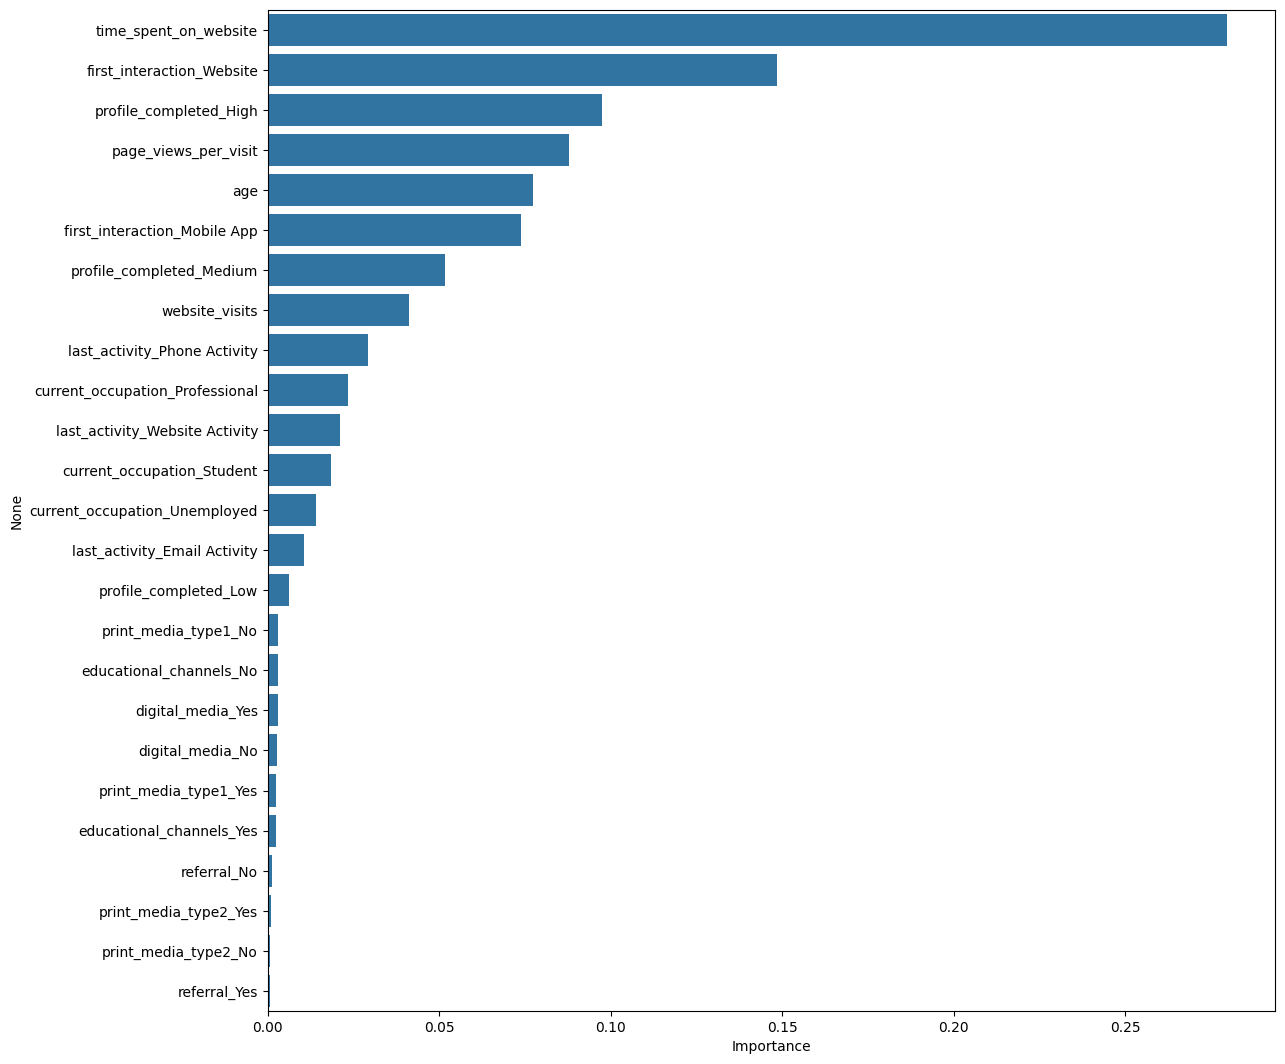

In [ ]:
#checking importance of tuned random forest
importances = rf_estimator_tuned.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y=importance_df.index);

The top 3 important features have remained between the tuned decition tree and the tuned random forest

## Actionable Insights and Recommendations

 * Overall while the model has decent performance, there is room for improvement in this model. This could mean it requires additional hyperparameter tuning, updating the imbalance metrics to bias 1 more than the current distribution, or exploring alternative models that may perform better.
 * The model with the best recall overall was the tuned random forest, however the recall for class 1 on the test data was only 0.78 compared to 0.86 for class 1 on the test data for the tuned decision tree.
 * Individuals who spent more time on the website, first interacted with ExtraaLean through their website, completed at least 75% of their profile and are above age 25 were driving factors for if they converted to a paying customer. (when looking at the random forest)
 * Using the tuned decision tree to drive decisions we see a similar trend but the only contributing factors being time spent on the website, first interaction was with the website, 50-75% profile completion (medium), age, and website last activity.
 * ExtraaLean should focus on getting traffic to their website and getting individuals to fill in at least 50% of the profile. They could also benefit from targeting indivduals who older (over 25 based on the tree).
 * Updating the website to drive traffic and interaction could lead to more conversions as well as getting information such as age as early as possible.

In [ ]:
%%shell
jupyter nbconvert --to html "/content/Full Code Version - Potential Customers Prediction_Corazzin.ipynb"

[NbConvertApp] Converting notebook /content/Full Code Version - Potential Customers Prediction_Corazzin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 39 image(s).
[NbConvertApp] Writing 2421362 bytes to /content/Full Code Version - Potential Customers Prediction_Corazzin.html
